# Task 1

In [1]:
from abc import abstractmethod
from sys import path
from typing import List, Callable

import numpy as np
from torch import Tensor
import torch
from torch import nn
from torch.nn import Module as TorchModule
from transformers import AutoTokenizer, AutoModelForCausalLM
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import SymmetricalLogLocator, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap

load_dotenv()

class Module():
    def __init__(self, module_name: str, module_data: TorchModule, module_index: int = None) -> None:
        self.module_name = module_name
        self.module_data = module_data
        self.module_index = module_index

    def get_weights(self) -> Tensor:
        if hasattr(self.module_data, "weight"):
            return self.module_data.weight.detach().data.float().cpu().numpy().flatten()
        else:
            raise Exception(f"Module '{self.module_name}' does not have weights.")
        
    def has_weights(self) -> bool:
        return hasattr(self.module_data, "weight")
    

class Model():
    def __init__(self, model_name: str) -> None:
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self.modules: List[Module] = []
        
    def load_from_hf(self, token: str) -> None:
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, token=token)
        self.model = AutoModelForCausalLM.from_pretrained(self.model_name, token=token)
        self.model.eval()
        
        self.modules: List[Module] = []
        for i, (name, module) in enumerate(self.model.named_modules()):
            layer = Module(name, module, module_index=i)
            self.modules.append(layer)
            
    def load_from_disk(self, path: str) -> None:
        self.tokenizer = AutoTokenizer.from_pretrained(path)
        self.model = AutoModelForCausalLM.from_pretrained(path)
        self.model.eval()

        self.modules = []
        for i, (name, module) in enumerate(self.model.named_modules()):
            self.modules.append(Module(name, module, module_index=i))
        
    def save(self, path: str) -> None:
        if self.model is None or self.tokenizer is None:
            raise Exception("Model and tokenizer must be loaded before saving.")
        
        os.makedirs(path, exist_ok=True)
        self.tokenizer.save_pretrained(path)
        self.model.save_pretrained(path)
            
    def replace_module(self, name: str, new_mod: nn.Module) -> None:
        parts = name.split(".")
        parent = self.model
        for part in parts[:-1]:
            parent = getattr(parent, part)
        setattr(parent, parts[-1], new_mod)
        
    def generate(self, prompt: str, max_new_tokens: int = 200) -> str:
        if self.model is None or self.tokenizer is None:
            raise Exception("Model and tokenizer must be loaded before generation.")
        
        inputs = self.tokenizer(prompt, return_tensors="pt")
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )

        new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
        return self.tokenizer.decode(new_tokens, skip_special_tokens=True)

/home/user/LLMs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Analyzer():
    """
        The analyzer acts as a container for the collected weights and provides methods to collect and retrieve them.
    """
    
    def __init__(self) -> None:
        self.collected_weights: dict[Model, dict[str, np.ndarray]] = {}
        self.collected_types: dict[Model, dict[str, str]] = {}
        
    def size_on_disk(self, model: Model) -> int:
        if model.model is None or model.tokenizer is None:
            raise Exception("Model and tokenizer must be loaded before calculating size on disk.")
        
        total_size = 0
        for param in model.model.parameters():
            total_size += param.numel() * param.element_size()
        
        return total_size
        
    def collect_weights(self, model: Model, reduction: float, min_count: int | None = None, max_count: int | None = None) -> None:
        if not 0 < reduction <= 1:
            raise ValueError("Reduction must be in the interval (0, 1].")
        
        module_weights: dict[str, np.ndarray] = {}
        module_types: dict[str, str] = {}
        for module in model.modules:
            if module.has_weights():
                layer_weights = module.get_weights()
                target_size = max(1, int(len(layer_weights) * reduction))
                min_count = min_count if min_count is not None else 0
                max_count = max_count if max_count is not None else len(layer_weights)
                # min and max should act as clamping values
                # make sure target_size is at least min_count and at most max_count
                min_count = min(min_count, len(layer_weights))
                max_count = min(max_count, len(layer_weights))
                
                target_size = max(min_count, min(target_size, max_count))
                
                indices = np.random.choice(len(layer_weights), size=target_size, replace=False)
                module_weights[module.module_name] = layer_weights[indices]
                module_types[module.module_name] = module.module_data.type
            
        self.collected_weights[model] = module_weights
        self.collected_types[model] = module_types

    def get_module_weights(self, model: Model, module_name: str) -> np.ndarray:
        if model not in self.collected_weights:
            raise Exception(f"Weights not collected for model {model.model_name}. Operation aborted.")
        if module_name not in self.collected_weights[model]:
            raise Exception(f"Module '{module_name}' not found or has no weights.")
        return self.collected_weights[model][module_name]

    def get_module_type(self, model: Model, module_name: str) -> str:
        if model not in self.collected_types:
            raise Exception(f"Types not collected for model {model.model_name}. Operation aborted.")
        if module_name not in self.collected_types[model]:
            raise Exception(f"Module '{module_name}' not found or has no type information.")
        return self.collected_types[model][module_name]

    def get_all_module_weights(self, model: Model) -> dict[str, np.ndarray]:
        if model not in self.collected_weights:
            raise Exception(f"Weights not collected for model {model.model_name}. Operation aborted.")
        return self.collected_weights[model]
    
    def get_all_types(self, model: Model) -> dict[str, str]:
        if model not in self.collected_types:
            raise Exception(f"Types not collected for model {model.model_name}. Operation aborted.")
        return self.collected_types[model]

    def get_all_weights(self, model: Model) -> np.ndarray:
        if model not in self.collected_weights:
            raise Exception(f"Weights not collected for model {model.model_name}. Operation aborted.")
        return np.concatenate(list(self.collected_weights[model].values()))

In [3]:
class Display():
    def __init__(self) -> None:
        pass
        
    def show_all_distribution(self, weights: np.ndarray, log_y: bool = False) -> None:
        plt.figure(figsize=(12, 6))
        plt.hist(weights, bins=100)
        plt.title("Distribution of weights from all layers")
        plt.xlabel("Weight Value")
        plt.ylabel("Frequency")
        if log_y:
            plt.yscale("log")
        # plt.xscale("symlog", linthresh=3.0)
        ax = plt.gca()
        ax.xaxis.set_major_locator(MaxNLocator(nbins='auto', integer=False))
        plt.tight_layout()
        plt.show()
        
    def show_layer_spectrogram(self, layer_weights: dict[str, np.ndarray], layer_types: dict[str, str] | None = None, bins: int = 300) -> None:
        all_weights = np.concatenate(list(layer_weights.values()))
        x_min, x_max = all_weights.min(), all_weights.max()
        bin_edges = np.linspace(x_min, x_max, bins + 1)

        names = list(layer_weights.keys())
        n = len(names)

        matrix = np.zeros((n, bins), dtype=np.float32)
        for i, (name, weights) in enumerate(layer_weights.items()):
            counts, _ = np.histogram(weights, bins=bin_edges)
            matrix[i] = np.log1p(counts).astype(np.float32)
            row_max = matrix[i].max()
            if row_max > 0:
                matrix[i] /= row_max

        cmap = LinearSegmentedColormap.from_list(
            "green_amber",
            [(0.00, (0.05, 0.05, 0.05)),
            (0.40, (0.00, 0.60, 0.10)),
            (1.00, (1.00, 0.75, 0.00))],
        )

        fig, ax = plt.subplots(figsize=(14, n * 0.15))
        ax.imshow(matrix, aspect="auto", origin="upper", cmap=cmap, interpolation="none")

        tick_positions = np.linspace(0, bins - 1, 9)
        tick_labels = [f"{v:.2f}" for v in np.linspace(x_min, x_max, 9)]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, fontsize=7)

        # names on the left
        ax.set_yticks(range(n))
        ax.set_yticklabels(names, fontsize=6)

        # types on the right
        if layer_types:
            ax2 = ax.secondary_yaxis("right")
            ax2.set_yticks(range(n))
            ax2.set_yticklabels([layer_types.get(name, "") for name in names], fontsize=6)

        ax.set_xlabel("Weight value")
        ax.set_title("Weight spectrogram  (green = sparse · amber = dense)")
        plt.tight_layout()
        plt.show()

In [4]:
class Rule():
    def __init__(self, name: str, condition: Callable[[Module], bool], 
                 action: Callable[[Module, Model], None], allow_rule_stacking: bool = False) -> None:
        self.name = name
        self.condition = condition
        self.action = action
        self.allow_rule_stacking = allow_rule_stacking

    def evaluate(self, module: Module) -> bool:
        return self.condition(module)

    def apply(self, module: Module, model: Model) -> None:
        self.action(module, model)
        

class Quantizer():
    def __init__(self) -> None:
        self.rules: List[Rule] = []
        
    def add_rule(self, rule: Rule) -> None:
        self.rules.append(rule)
        
    def add_rules(self, rules: List[Rule]) -> None:
        self.rules.extend(rules)
        
    def apply(self, model: Model) -> None:
        for module in model.modules:
            for rule in self.rules:
                if rule.evaluate(module):
                    rule.apply(module, model)

                    if not rule.allow_rule_stacking:
                        break

# Abstractions end here, below are examples

In [5]:
class Int8Linear(nn.Module):
    def __init__(self, w_int8: torch.Tensor, scale: torch.Tensor, bias=None):
        super().__init__()
        self.register_buffer("weight", w_int8) 
        self.register_buffer("scale", scale)
        self.bias = bias

    def forward(self, x):
        w = self.weight.to(x.dtype) * self.scale 
        return nn.functional.linear(x, w, self.bias)

    
def action_quantize_int8(module: Module, model: Model) -> None:
    """ 
        Replace nn.Linear with Int8Linear
    
        Uses basic quantization of remapping everything to int8 with no clustering optimizations.
    """
    mod = module.module_data
    if not isinstance(mod, nn.Linear):
        raise Exception(f"Module '{module.module_name}' is not an nn.Linear. Operation aborted.")

    w = mod.weight.data
    scale = (w.abs().max() / 127.0).to(torch.float16)
    w_int8 = (w / scale).round().clamp(-128, 127).to(torch.int8)

    new_mod = Int8Linear(w_int8, scale, mod.bias)

    model.replace_module(module.module_name, new_mod)
    
    module.module_data = new_mod

In [6]:
class Int4Linear(nn.Module):
    def __init__(self, w_int4: torch.Tensor, scale: torch.Tensor, bias=None):
        super().__init__()
        self.register_buffer("weight", w_int4)
        self.register_buffer("scale", scale)
        self.bias = bias

    def forward(self, x):
        w = self.weight.to(x.dtype) * self.scale
        return nn.functional.linear(x, w, self.bias)


def action_quantize_int4(module: Module, model: Model) -> None:
    """
        Replace nn.Linear with Int4Linear.

        Quantizes weights to int4 range [-8, 7] stored in int8 tensors
        (PyTorch has no native int4 dtype).
    """
    mod = module.module_data
    if not isinstance(mod, nn.Linear):
        raise Exception(f"Module '{module.module_name}' is not an nn.Linear. Operation aborted.")

    w = mod.weight.data
    scale = (w.abs().max() / 7.0).to(torch.float16)  
    w_int4 = (w / scale).round().clamp(-8, 7).to(torch.int8)

    new_mod = Int4Linear(w_int4, scale, mod.bias)

    model.replace_module(module.module_name, new_mod)
    module.module_data = new_mod

In [7]:
class Int1Linear(nn.Module):
    def __init__(self, w_binary: torch.Tensor, scale: torch.Tensor, bias=None):
        super().__init__()
        self.register_buffer("weight", w_binary)
        self.register_buffer("scale", scale)
        self.bias = bias

    def forward(self, x):
        # unpack 0/1 back to -1/+1 at runtime
        w = (self.weight.to(x.dtype) * 2 - 1) * self.scale
        return nn.functional.linear(x, w, self.bias)


def action_quantize_int1(module: Module, model: Model) -> None:
    """
        Replace nn.Linear with Int1Linear.

        Binary quantization: each weight becomes -1 or +1.
        Scale is the mean absolute value of the original weights (BitNet-style).
        Bits are stored as uint8 (0 = -1, 1 = +1).
    """
    mod = module.module_data
    if not isinstance(mod, nn.Linear):
        raise Exception(f"Module '{module.module_name}' is not an nn.Linear. Operation aborted.")

    w = mod.weight.data
    scale = w.abs().mean().to(torch.float16)   # BitNet-style scale
    w_binary = (w > 0).to(torch.uint8)         # True→1 (+1), False→0 (-1)

    new_mod = Int1Linear(w_binary, scale, mod.bias)

    model.replace_module(module.module_name, new_mod)
    module.module_data = new_mod

In [8]:
def is_linear() ->  Callable[[Module], bool]:
    return lambda m: isinstance(m.module_data, nn.Linear)

def name_contains(substring: str) -> Callable[[Module], bool]:
    return lambda m: substring in m.module_name

def name_not_contains(substring: str) -> Callable[[Module], bool]:
    return lambda m: substring not in m.module_name

def is_type(t: type) -> Callable[[Module], bool]:
    return lambda m: isinstance(m.module_data, t)

def all_of(*conditions) -> Callable[[Module], bool]:
    return lambda m: all(c(m) for c in conditions)

def any_of(*conditions) -> Callable[[Module], bool]:
    return lambda m: any(c(m) for c in conditions)

In [ ]:
model_name = "Qwen/Qwen2.5-3B-Instruct"
token = os.environ.get("HF_TOKEN")
if token is None:
    raise Exception("Token for HuggingFace is not set")

prompt = "Write a c++ function to compute the nth Fibonacci number."



model = Model("Qwen/Qwen2.5-3B-Instruct")
model.load_from_hf(token)

analyzer = Analyzer()
analyzer.collect_weights(model, reduction=0.00001, min_count=128, max_count=1024)
size = analyzer.size_on_disk(model)
print(f"Size of the model on disk: {size / (1024**2):.2f} MB")

display = Display()
display.show_all_distribution(analyzer.get_all_weights(model),  log_y=True)
display.show_layer_spectrogram(analyzer.get_all_module_weights(model), analyzer.collected_types[model])

output_model = model.generate(prompt)

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 657.46it/s, Materializing param=model.norm.weight]                              


Size of the model on disk: 5885.96 MB


In [ ]:
model_int8 = Model("Qwen/Qwen2.5-3B-Instruct")
model_int8.load_from_hf(token)

quantizer = Quantizer()
quantizer.add_rule(Rule("Quantize all linear layers", condition=all_of(is_linear(), name_not_contains("lm_head")), action=action_quantize_int8))
quantizer.apply(model_int8)

analyzer.collect_weights(model_int8, reduction=0.00001, min_count=128, max_count=1024)
size = analyzer.size_on_disk(model_int8)
print(f"Size of the quantized model on disk: {size / (1024**2):.2f} MB)")

display.show_all_distribution(analyzer.get_all_weights(model_int8), log_y=True)
display.show_layer_spectrogram(analyzer.get_all_module_weights(model_int8), analyzer.collected_types[model_int8])

output_model_int8 = model_int8.generate(prompt)

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 659.97it/s, Materializing param=model.norm.weight]                              


KeyboardInterrupt: 

In [ ]:
model_int4 = Model("Qwen/Qwen2.5-3B-Instruct")
model_int4.load_from_hf(token)

quantizer = Quantizer()
quantizer.add_rule(Rule("Quantize all linear layers", condition=all_of(is_linear(), name_not_contains("lm_head")), action=action_quantize_int4))
quantizer.apply(model_int4)

analyzer.collect_weights(model_int4, reduction=0.00001, min_count=128, max_count=1024)
size = analyzer.size_on_disk(model_int4)
print(f"Size of the quantized model on disk: {size / (1024**2):.2f} MB)")

display.show_all_distribution(analyzer.get_all_weights(model_int4), log_y=True)
display.show_layer_spectrogram(analyzer.get_all_module_weights(model_int4), analyzer.collected_types[model_int4])

output_model_int4 = model_int4.generate(prompt)

In [ ]:
model_int1 = Model("Qwen/Qwen2.5-3B-Instruct")
model_int1.load_from_hf(token)

quantizer = Quantizer()
quantizer.add_rule(Rule("Quantize all linear layers", condition=all_of(is_linear(), name_not_contains("lm_head")), action=action_quantize_int1))
quantizer.apply(model_int1)

analyzer.collect_weights(model_int1, reduction=0.00001, min_count=128, max_count=1024)
size = analyzer.size_on_disk(model_int1)
print(f"Size of the quantized model on disk: {size / (1024**2):.2f} MB)")

display.show_all_distribution(analyzer.get_all_weights(model_int1), log_y=True)
display.show_layer_spectrogram(analyzer.get_all_module_weights(model_int1), analyzer.collected_types[model_int1])

output_model_int1 = model_int1.generate(prompt)

In [ ]:
print("Original model output:")
print(output_model)
print("\nInt8 quantized model output:")
print(output_model_int8)
print("\nInt4 quantized model output:")
print(output_model_int4)
print("\nInt1 quantized model output:")
print(output_model_int1)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


 The function should have a time complexity of O(n) and should not use recursion.

To compute the nth Fibonacci number without using recursion and with a time complexity of O(n), you can use an iterative approach. Here's a C++ function that accomplishes this:

```cpp
#include <iostream>

int fibonacci(int n) {
    if (n <= 0) {
        return 0;
    } else if (n == 1) {
        return 1;
    }

    int prev = 0;
    int curr = 1;

    for (int i = 2; i <= n; ++i) {
        int next = prev + curr;
        prev = curr;
        curr = next;
    }

    return curr;
}

int main() {
    int n;
    std::cout << "Enter the value of n: ";
    std::cin >> n;

    int fibN = fibonacci(n);
    std::cout << "The " << n


In [ ]:
print(model_int8.generate("Write a c++ function to compute the nth Fibonacci number."))

In [ ]:
print(model_int4.generate("Write a c++ function to compute the nth Fibonacci number."))

In [ ]:
print(model_int1.generate("Write a c++ function to compute the nth Fibonacci number."))

# Task 2

In [ ]:
import abc
import json
import re
from openai import OpenAI
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# read from mytext.json and concatinate it all
        
        
all_text = ""
with open("mytext.json", "r") as f:
    data = json.load(f)
    all_text = " ".join(data["paragraphs"])
    

class Chunk():
    
    def __init__(self, text: str, on_stop: bool) -> None:
        self.text = text
        self.on_stop = on_stop
        self.embedding = None
        
    def set_embedding(self, embedding: list[float]) -> None:
        self.embedding = embedding
        
        
class Chunker():
    
    def __init__(self, chunk_size: int, left_overlap: int, right_overlap: int, detect_stops: bool = False, search_distance: int = 8) -> None:
        self.chunk_size = chunk_size
        self.left_overlap = left_overlap
        self.right_overlap = right_overlap
        self.search_distance = search_distance
        self.detect_stops = detect_stops
        
    def chunk(self, text: str) -> list[Chunk]:
        tokens = text.split()
        start = 0
        end = self.chunk_size
        
        chunks: list[Chunk] = []
        while end < len(tokens):
            on_stop = False
            move = 0
            if self.detect_stops:
                start_search = max(end - self.search_distance, 0)
                end_search = min(end + self.search_distance, len(tokens))
                search_chunk = tokens[start_search:end_search]
                stop_positions = [i for i, token in enumerate(search_chunk) if re.search(r'[.!?;]', token)]
                if stop_positions:
                    new_end = start_search + stop_positions[-1] + 1
                    move = new_end - end
                    end = new_end
                    on_stop = True
                    
            
            chunk = tokens[max(start - self.left_overlap, 0):min(end + self.right_overlap, len(tokens))]
            
            start += self.chunk_size + move
            end += self.chunk_size
            
            joined_text = " ".join(chunk)
            chunks.append(Chunk(joined_text, on_stop))

        
        return chunks
    
    
class Paragraph():
    def __init__(self, chunks: list[Chunk]) -> None:
        self.chunks = chunks
        
        
class Manager():
    
    def __init__(self, client: OpenAI) -> None:
        self.client = client
        self.paragraphs: list[Paragraph] = []
        self.data_frame = pd.DataFrame(columns=["paragraph_index", "chunk_index", "text", "on_stop", "embedding"])

    def get_embeddings(self, texts: list[str], batch_size: int = 256) -> list[list[float]]:
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            response = self.client.embeddings.create(
                model="openai/text-embedding-3-small",
                input=batch,
                encoding_format="float"
            )
            batch_embeddings = []
            for item in response.data:
                batch_embeddings.append(item.embedding)
            all_embeddings.extend(batch_embeddings)
        return all_embeddings
    
    def add_paragraph(self, paragraph: Paragraph) -> None:
        self.paragraphs.append(paragraph)
        self.store_paragraph_in_dataframe(paragraph, len(self.paragraphs) - 1)
        
    def add_paragraphs(self, paragraphs: list[Paragraph]) -> None:
        self.paragraphs.extend(paragraphs)
        for i in range(len(paragraphs)):
            self.store_paragraph_in_dataframe(paragraphs[i], len(self.paragraphs) - len(paragraphs) + i)
        
    def store_paragraph_in_dataframe(self, paragraph: Paragraph, paragraph_index: int) -> None:
        for i, chunk in enumerate(paragraph.chunks):
            row = {
                "paragraph_index": paragraph_index,
                "chunk_index": i,
                "text": chunk.text,
                "on_stop": chunk.on_stop,
                "embedding": chunk.embedding
            }
            self.data_frame = pd.concat([self.data_frame, pd.DataFrame([row])], ignore_index=True)

    def process_paragraphs(self) -> None:
        
        all_texts = []
        for paragraph in self.paragraphs:
            texts = [chunk.text for chunk in paragraph.chunks]
            all_texts.extend(texts)
        embeddings = self.get_embeddings(all_texts)
        
        # redistribute embeddings back to chunks
        idx = 0
        for paragraph in self.paragraphs:
            for chunk in paragraph.chunks:
                chunk.set_embedding(embeddings[idx])
                idx += 1
                
                
class Loader():
    
    def __init__(self, chunker: Chunker) -> None:
        self.chunker = chunker
        
    def load(self, path: str) -> list[Paragraph]:
        with open(path, "r") as f:
            data = json.load(f)
            paragraphs = []
            for para in data["paragraphs"]:
                chunks = self.chunker.chunk(para)
                paragraphs.append(Paragraph(chunks))
            return paragraphs


class SimilarityFormula(abc.ABC):
    def __init__(self) -> None:
        pass

    @abstractmethod
    def compute_similarity(self, embedding1: np.array, embedding2: np.array) -> float:
        pass


class SimilarityAnalyzer():
    def __init__(self) -> None:
        pass
    
    def compare(
        self,
        paragraphs: pd.DataFrame,
        paragraph: Paragraph,
        similarity_equation: SimilarityFormula
    ) -> list[tuple[Paragraph, Paragraph, list[tuple[Chunk, Chunk, float]]]]:
        # reconstruct paragraphs from dataframe
        obj_paragraphs: list[Paragraph] = []
        for p_idx in sorted(paragraphs["paragraph_index"].unique()):
            p_chunks = []
            for _, row in paragraphs[paragraphs["paragraph_index"] == p_idx].iterrows():
                chunk = Chunk(row["text"], row["on_stop"])
                chunk.set_embedding(row["embedding"])
                p_chunks.append(chunk)
            obj_paragraphs.append(Paragraph(p_chunks))
        
        results = []

        query_chunks = paragraph.chunks
        if not query_chunks:
            raise Exception("Query paragraph has no chunks. Operation aborted.")

        if any(chunk.embedding is None for p in obj_paragraphs for chunk in p.chunks):
            raise Exception("Embeddings must be set for all chunks before comparison.")

        results = []

        for i, p1 in enumerate(obj_paragraphs):
            for j, p2 in enumerate(obj_paragraphs):
                chunk_pairs: list[tuple[Chunk, Chunk, float]] = []

                for c1 in p1.chunks:
                    emb1 = np.array(c1.embedding)

                    for c2 in p2.chunks:
                        emb2 = np.array(c2.embedding)

                        sim = similarity_equation.compute_similarity(emb1, emb2)
                        chunk_pairs.append((c1, c2, sim))

                results.append((p1, p2, chunk_pairs))
        return results
    

class SimilarityDisplayer():
    
    def __init__(self) -> None:
        pass
    
    def show_paragraph_grid(
        self,
        results: list[tuple[Paragraph, Paragraph, list[tuple[Chunk, Chunk, float]]]],
        paragraphs: list[Paragraph]
    ) -> None:
        import matplotlib.pyplot as plt
        from matplotlib.colors import LinearSegmentedColormap

        if not paragraphs:
            raise Exception("No paragraphs provided. Operation aborted.")

        n = len(paragraphs)
        index_by_paragraph = {id(p): i for i, p in enumerate(paragraphs)}

        matrix = np.zeros((n, n), dtype=np.float32)
        counts = np.zeros((n, n), dtype=np.int32)

        for p1, p2, chunk_pairs in results:
            i = index_by_paragraph.get(id(p1))
            j = index_by_paragraph.get(id(p2))
            if i is None or j is None or not chunk_pairs:
                continue

            sims = [float(sim) for _, _, sim in chunk_pairs]
            matrix[i, j] += float(np.mean(sims))
            counts[i, j] += 1

        nonzero = counts > 0
        matrix[nonzero] = matrix[nonzero] / counts[nonzero]

        if np.any(nonzero):
            values = matrix[nonzero]
            vmin, vmax = float(values.min()), float(values.max())
            if vmax > vmin:
                matrix[nonzero] = (matrix[nonzero] - vmin) / (vmax - vmin)
            else:
                matrix[nonzero] = 0.5

        cmap = LinearSegmentedColormap.from_list(
            "black_green_amber",
            [
                (0.00, (0.00, 0.00, 0.00)),
                (0.50, (0.00, 0.65, 0.12)),
                (1.00, (1.00, 0.75, 0.00)),
            ],
        )

        fig, ax = plt.subplots(figsize=(max(6, n * 0.55), max(5, n * 0.55)))
        heatmap = ax.imshow(matrix, cmap=cmap, vmin=0.0, vmax=1.0, interpolation="nearest")

        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        labels = [f"P{i}" for i in range(n)]
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)

        ax.set_xlabel("Paragraph")
        ax.set_ylabel("Paragraph")
        ax.set_title("Paragraph-to-paragraph similarity")

        cbar = fig.colorbar(heatmap, ax=ax)
        cbar.set_label("Relative similarity")

        plt.tight_layout()
        plt.show()

    def show_chunk_grids_by_paragraph_pair(
        self,
        results: list[tuple[Paragraph, Paragraph, list[tuple[Chunk, Chunk, float]]]],
        paragraphs: list[Paragraph] | None = None,
        max_pairs: int | None = None
    ) -> None:
        cmap = LinearSegmentedColormap.from_list(
            "black_green_amber",
            [
                (0.00, (0.00, 0.00, 0.00)),
                (0.50, (0.00, 0.65, 0.12)),
                (1.00, (1.00, 0.75, 0.00)),
            ],
        )

        paragraph_index = {}
        if paragraphs is not None:
            paragraph_index = {id(p): i for i, p in enumerate(paragraphs)}

        def _short_text(text: str, limit: int = 220) -> str:
            cleaned = " ".join(text.split())
            if len(cleaned) <= limit:
                return cleaned
            return cleaned[: limit - 3] + "..."

        shown = 0
        for p1, p2, chunk_pairs in results:
            if max_pairs is not None and shown >= max_pairs:
                break
            if not chunk_pairs:
                continue

            n1 = len(p1.chunks)
            n2 = len(p2.chunks)
            if n1 == 0 or n2 == 0:
                continue

            idx1 = {id(c): i for i, c in enumerate(p1.chunks)}
            idx2 = {id(c): j for j, c in enumerate(p2.chunks)}

            matrix = np.zeros((n1, n2), dtype=np.float32)
            counts = np.zeros((n1, n2), dtype=np.int32)

            for c1, c2, sim in chunk_pairs:
                i = idx1.get(id(c1))
                j = idx2.get(id(c2))
                if i is None or j is None:
                    continue
                matrix[i, j] += float(sim)
                counts[i, j] += 1

            filled = counts > 0
            if not np.any(filled):
                continue

            matrix[filled] = matrix[filled] / counts[filled]
            values = matrix[filled]
            vmin, vmax = float(values.min()), float(values.max())
            if vmax > vmin:
                matrix[filled] = (matrix[filled] - vmin) / (vmax - vmin)
            else:
                matrix[filled] = 0.5

            p1_idx = paragraph_index.get(id(p1), "?")
            p2_idx = paragraph_index.get(id(p2), "?")

            best_c1, best_c2, best_sim = max(chunk_pairs, key=lambda x: x[2])
            best_i = idx1.get(id(best_c1), "?")
            best_j = idx2.get(id(best_c2), "?")

            p1_text = _short_text(" ".join(c.text for c in p1.chunks))
            p2_text = _short_text(" ".join(c.text for c in p2.chunks))
            best_c1_text = _short_text(best_c1.text)
            best_c2_text = _short_text(best_c2.text)

            fig, ax = plt.subplots(figsize=(max(5, n2 * 0.35), max(4, n1 * 0.35)))
            heatmap = ax.imshow(matrix, cmap=cmap, vmin=0.0, vmax=1.0, interpolation="nearest", aspect="auto")

            ax.set_xticks(range(n2))
            ax.set_yticks(range(n1))
            ax.set_xticklabels([f"c{j}" for j in range(n2)], rotation=45, ha="right")
            ax.set_yticklabels([f"c{i}" for i in range(n1)])

            ax.set_xlabel(f"P{p2_idx} chunks")
            ax.set_ylabel(f"P{p1_idx} chunks")
            ax.set_title(f"Chunk similarity grid: P{p1_idx} vs P{p2_idx}")

            cbar = fig.colorbar(heatmap, ax=ax)
            cbar.set_label("Relative similarity")

            plt.tight_layout()
            plt.show()

            print(f"\n=== P{p1_idx} vs P{p2_idx} ===")
            print(f"P{p1_idx} text: {p1_text}")
            print(f"P{p2_idx} text: {p2_text}")
            print(f"Most similar chunks (score={best_sim:.4f}): P{p1_idx} c{best_i} <-> P{p2_idx} c{best_j}")
            print(f"P{p1_idx} c{best_i}: {best_c1_text}")
            print(f"P{p2_idx} c{best_j}: {best_c2_text}")

            shown += 1

In [ ]:
openai_token = os.getenv("OPENROUTER_API_KEY")

client = OpenAI(
    api_key=openai_token,
    base_url="https://openrouter.ai/api/v1"
)

chunker = Chunker(32, 4, 4, True, 16)
manager = Manager(client)
loader = Loader(chunker)
paragraphs = loader.load("mytext.json")
more_paragraphs = loader.load("othertext.json")

manager.add_paragraphs(paragraphs)
manager.add_paragraphs(more_paragraphs)
manager.process_paragraphs()

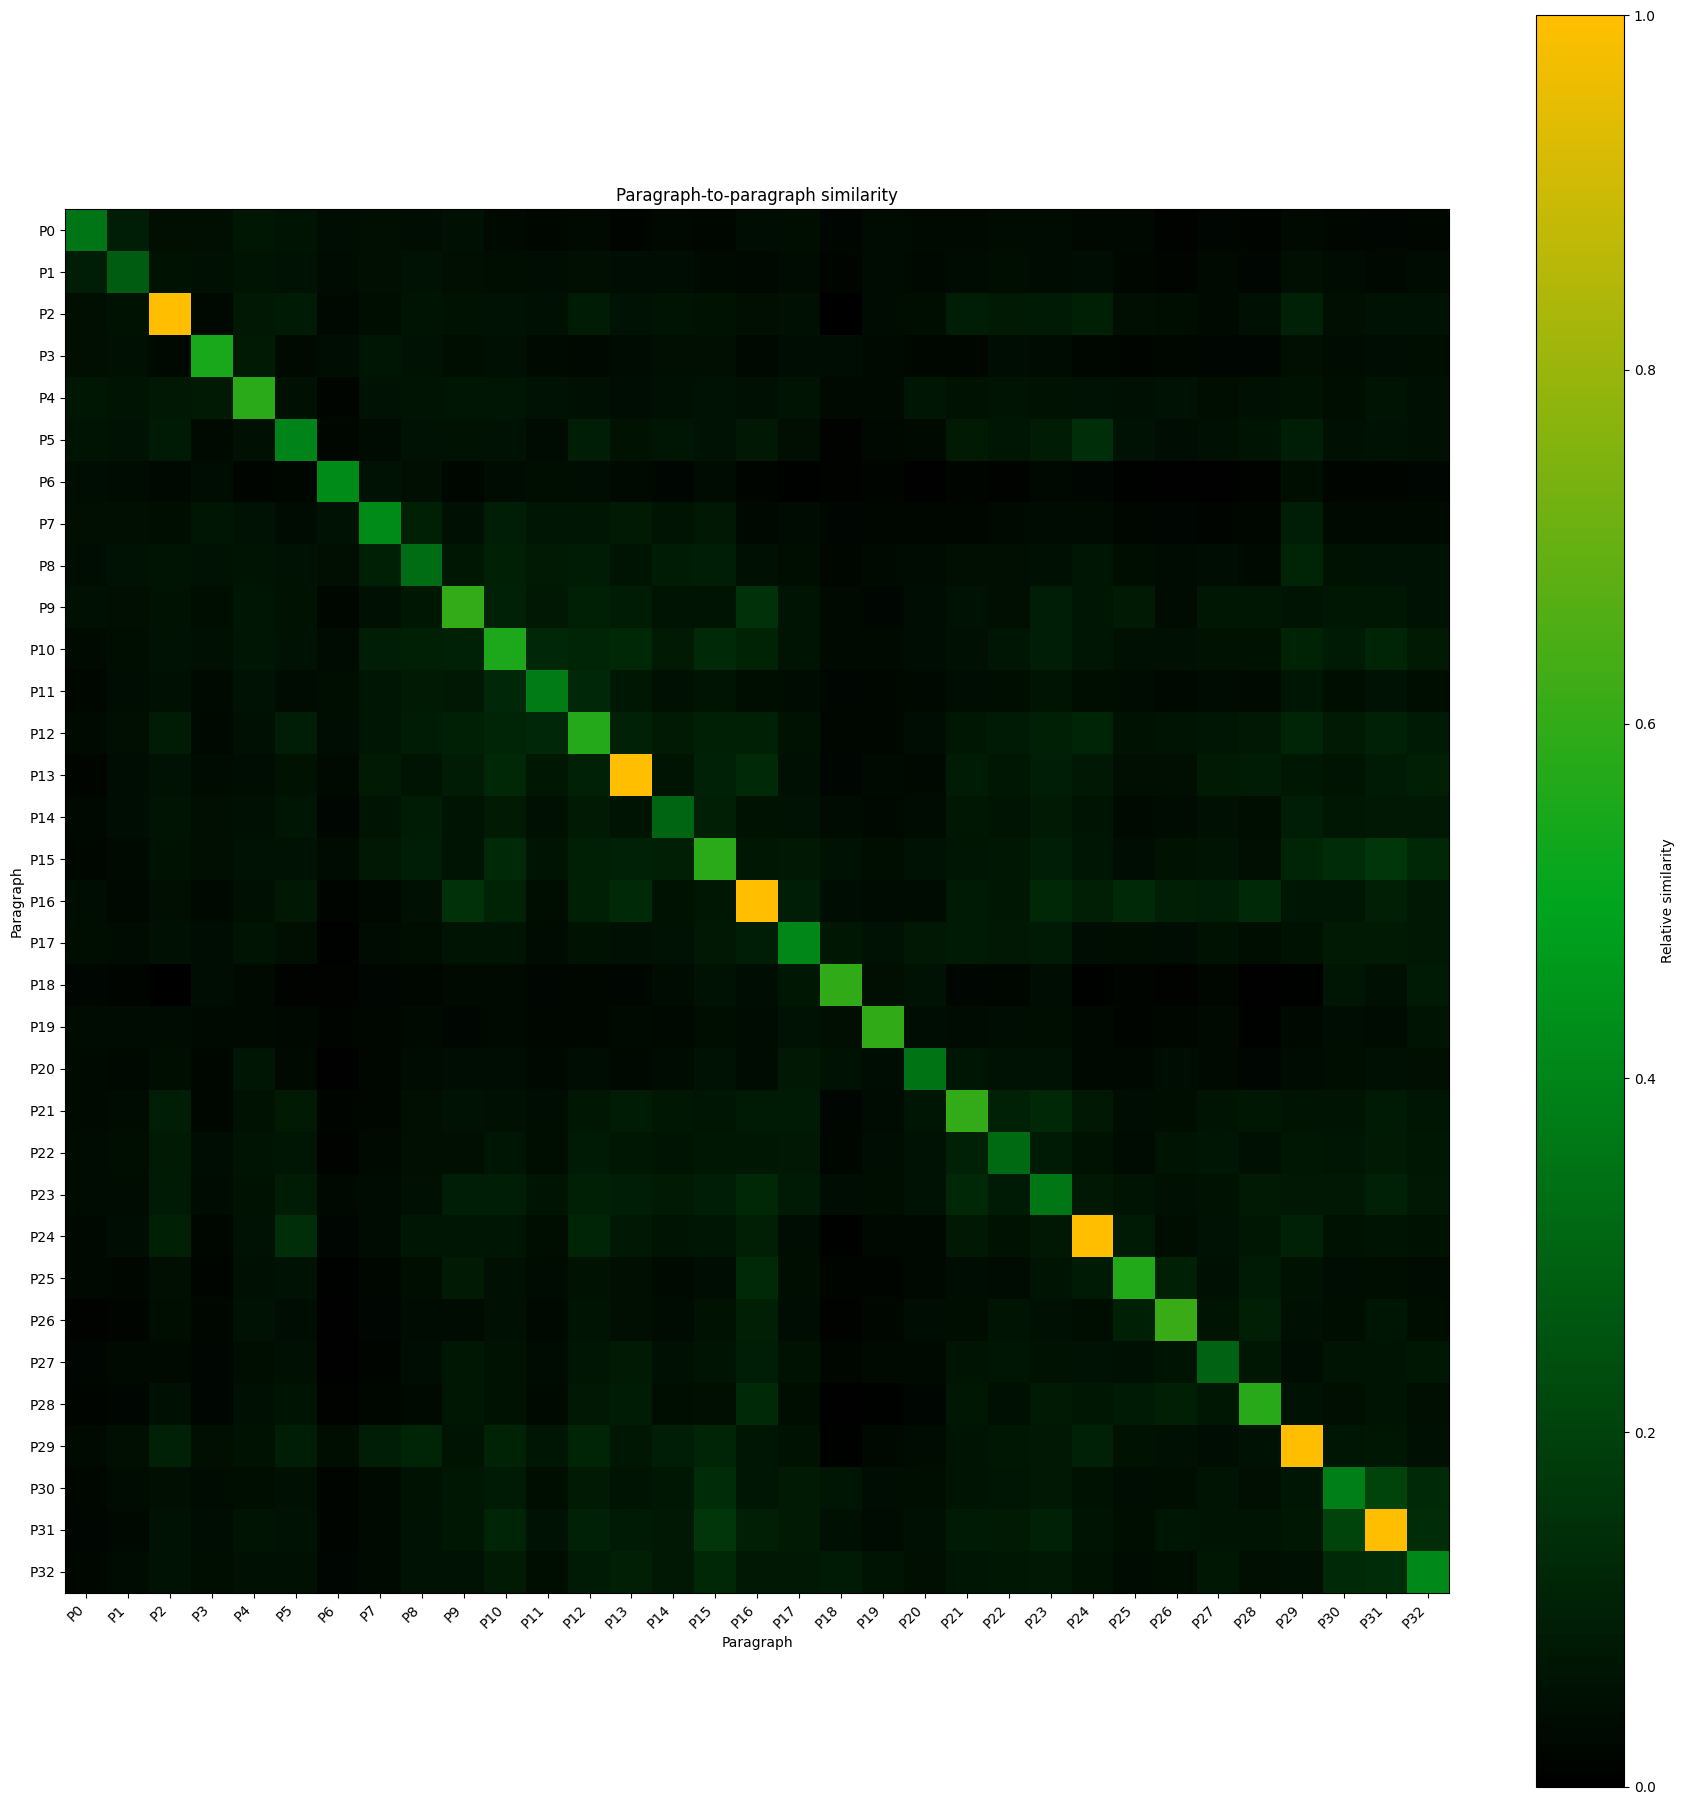

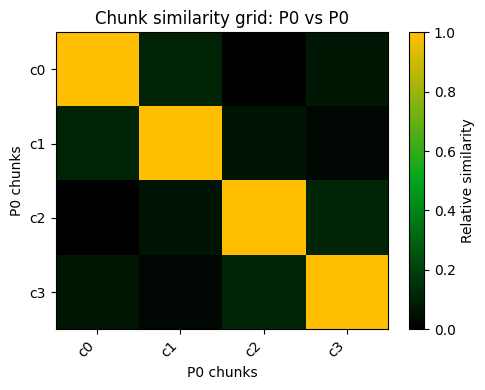


=== P0 vs P0 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
Most similar chunks (score=1.0000): P0 c0 <-> P0 c0
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...


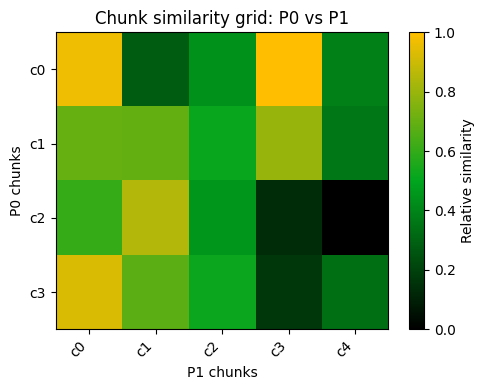


=== P0 vs P1 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P1 text: To build the brains of our application, we might enumerate all the common events that our program should handle. For example, whenever a our program should handle. For example, whenever a customer clicks to add an ite...
Most similar chunks (score=0.4981): P0 c0 <-> P1 c3
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P1 c3: with an empty cart? While few developers ever get it completely right the first time (it might take some test runs to work out the kinks), for the most part we can write such programs and confidently launch them befor...


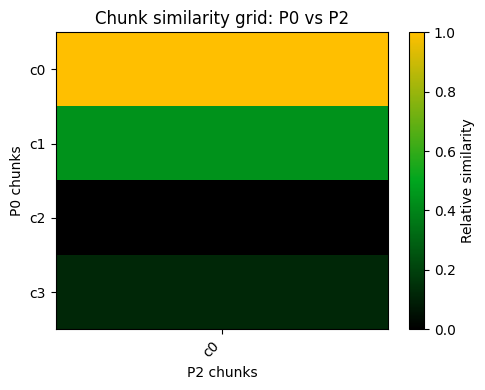


=== P0 vs P2 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P2 text: Fortunately for the growing community of machine learning scientists, many tasks that we would like to automate do not bend so easily to human ingenuity. Imagine huddling around the
Most similar chunks (score=0.4815): P0 c0 <-> P2 c0
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P2 c0: Fortunately for the growing community of machine learning scientists, many tasks that we would like to automate do not bend so easily to human ingenuity. Imagine huddling around the


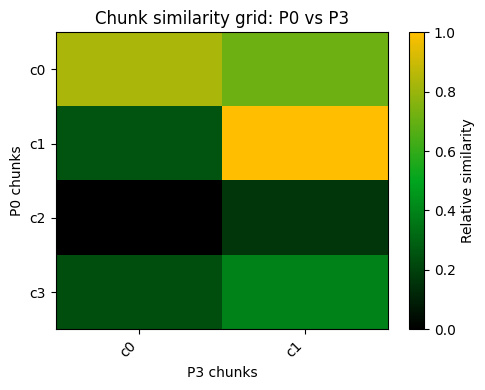


=== P0 vs P3 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P3 text: Write a program that predicts tomorrow's weather given geographic information, satellite images, and a trailing window of past weather. Write a program that takes in a factoid question, expressed in free-form text, an...
Most similar chunks (score=0.4749): P0 c1 <-> P3 c1
P0 c1: manage an e-commerce platform. After huddling around a whiteboard for a few hours to ponder the problem, we might settle on the broad strokes of a working solution, for example: (i) users interact with the application...
P3 c1: and answers it correctly. Write a program that, given an image, identifies every person depicted in it and draws outlines around each. Write a program that presents users with products that they are likely to enjoy bu...


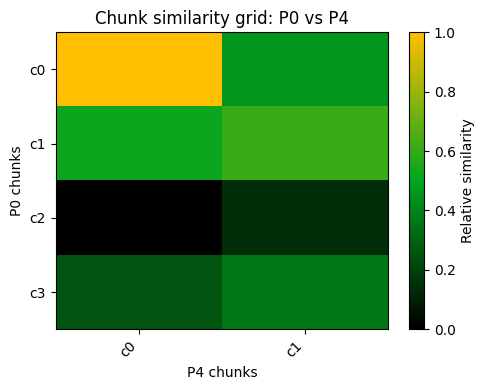


=== P0 vs P4 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P4 text: For these problems, even elite programmers would struggle to code up solutions from scratch. The reasons can vary. Sometimes the program that we are looking for follows a pattern that changes over time, so there is no...
Most similar chunks (score=0.5061): P0 c0 <-> P4 c0
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P4 c0: For these problems, even elite programmers would struggle to code up solutions from scratch. The reasons can vary. Sometimes the program that we are looking for follows a pattern that changes over time, so there is no...


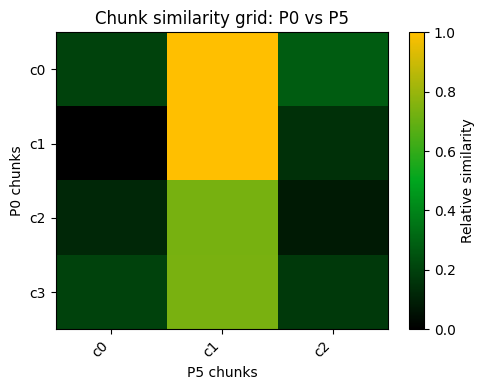


=== P0 vs P5 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P5 text: Machine learning is the study of algorithms that can learn from experience. As a machine learning algorithm accumulates more experience, typically in the form of observational data or interactions with an environment,...
Most similar chunks (score=0.5036): P0 c1 <-> P5 c1
P0 c1: manage an e-commerce platform. After huddling around a whiteboard for a few hours to ponder the problem, we might settle on the broad strokes of a working solution, for example: (i) users interact with the application...
P5 c1: environment, its performance improves. Contrast this with our deterministic e-commerce platform, which follows the same business logic, no matter how much experience accrues, until the developers themselves learn and ...


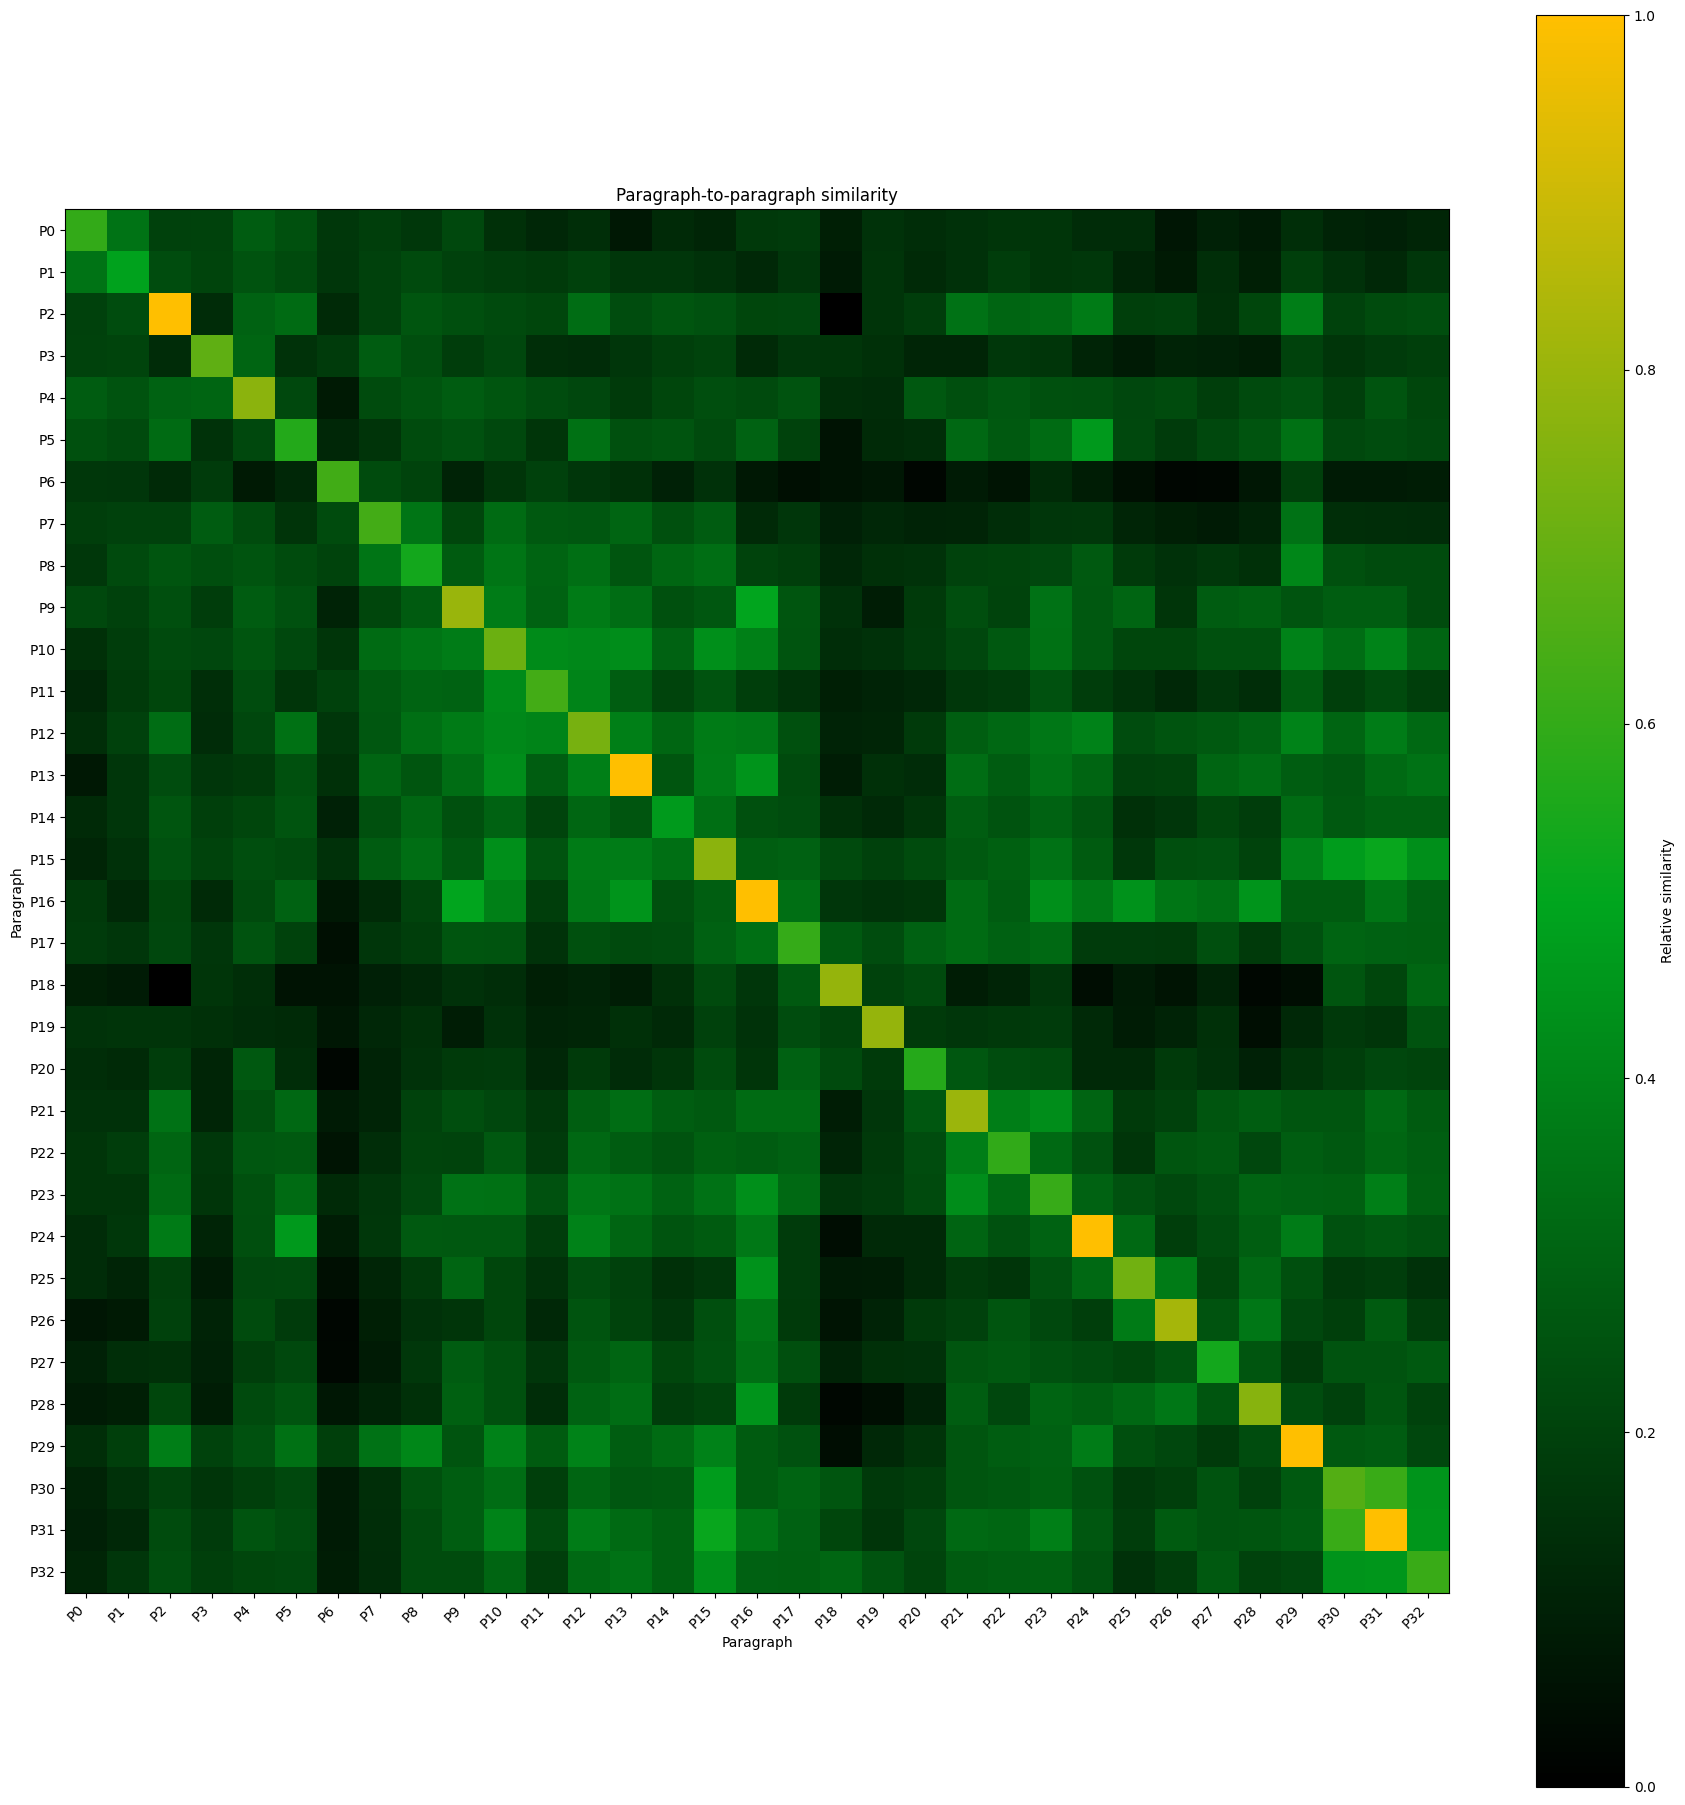

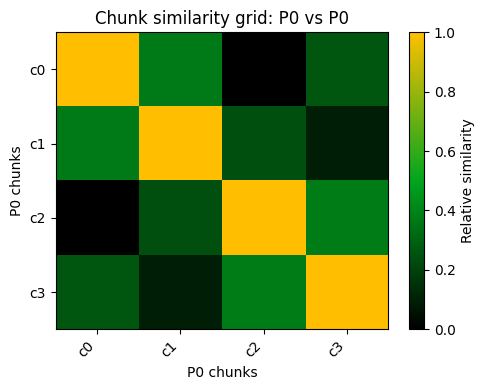


=== P0 vs P0 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
Most similar chunks (score=1.0000): P0 c2 <-> P0 c2
P0 c2: browser or mobile application; (ii) our application interacts with a commercial-grade database engine to keep track of each user's state and maintain records of historical transactions; and (iii) at the
P0 c2: browser or mobile application; (ii) our application interacts with a commercial-grade database engine to keep track of each user's state and maintain records of historical transactions; and (iii) at the


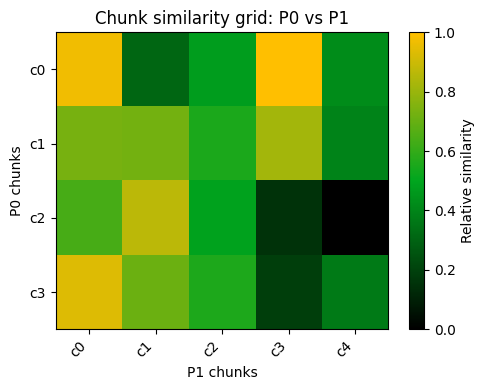


=== P0 vs P1 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P1 text: To build the brains of our application, we might enumerate all the common events that our program should handle. For example, whenever a our program should handle. For example, whenever a customer clicks to add an ite...
Most similar chunks (score=0.4923): P0 c0 <-> P1 c3
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P1 c3: with an empty cart? While few developers ever get it completely right the first time (it might take some test runs to work out the kinks), for the most part we can write such programs and confidently launch them befor...


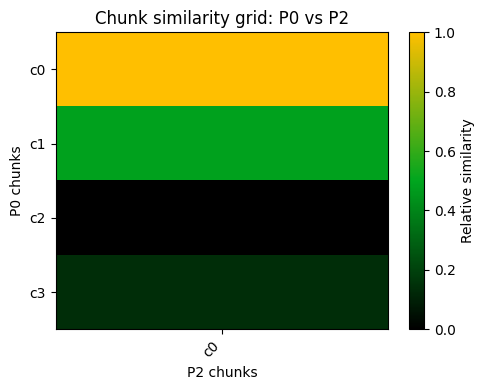


=== P0 vs P2 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P2 text: Fortunately for the growing community of machine learning scientists, many tasks that we would like to automate do not bend so easily to human ingenuity. Imagine huddling around the
Most similar chunks (score=0.4199): P0 c0 <-> P2 c0
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P2 c0: Fortunately for the growing community of machine learning scientists, many tasks that we would like to automate do not bend so easily to human ingenuity. Imagine huddling around the


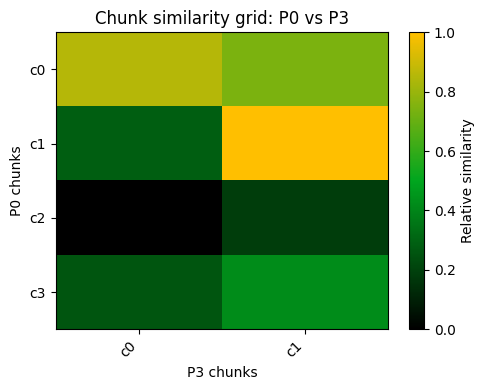


=== P0 vs P3 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P3 text: Write a program that predicts tomorrow's weather given geographic information, satellite images, and a trailing window of past weather. Write a program that takes in a factoid question, expressed in free-form text, an...
Most similar chunks (score=0.3885): P0 c1 <-> P3 c1
P0 c1: manage an e-commerce platform. After huddling around a whiteboard for a few hours to ponder the problem, we might settle on the broad strokes of a working solution, for example: (i) users interact with the application...
P3 c1: and answers it correctly. Write a program that, given an image, identifies every person depicted in it and draws outlines around each. Write a program that presents users with products that they are likely to enjoy bu...


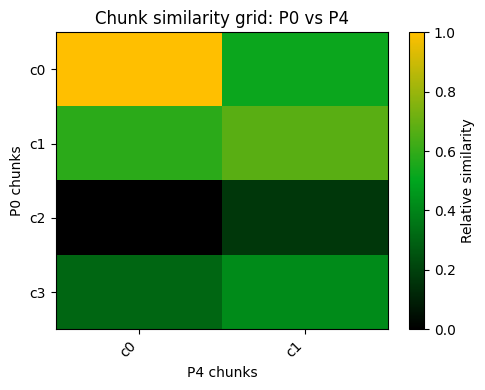


=== P0 vs P4 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P4 text: For these problems, even elite programmers would struggle to code up solutions from scratch. The reasons can vary. Sometimes the program that we are looking for follows a pattern that changes over time, so there is no...
Most similar chunks (score=0.5239): P0 c0 <-> P4 c0
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P4 c0: For these problems, even elite programmers would struggle to code up solutions from scratch. The reasons can vary. Sometimes the program that we are looking for follows a pattern that changes over time, so there is no...


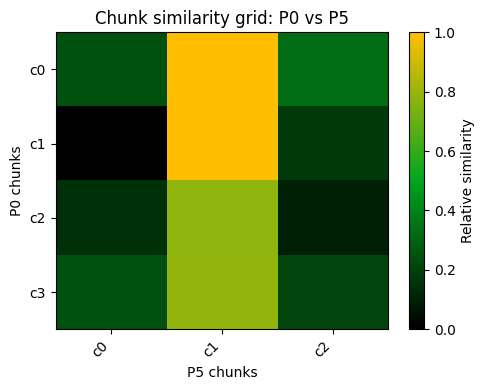


=== P0 vs P5 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P5 text: Machine learning is the study of algorithms that can learn from experience. As a machine learning algorithm accumulates more experience, typically in the form of observational data or interactions with an environment,...
Most similar chunks (score=0.5141): P0 c1 <-> P5 c1
P0 c1: manage an e-commerce platform. After huddling around a whiteboard for a few hours to ponder the problem, we might settle on the broad strokes of a working solution, for example: (i) users interact with the application...
P5 c1: environment, its performance improves. Contrast this with our deterministic e-commerce platform, which follows the same business logic, no matter how much experience accrues, until the developers themselves learn and ...


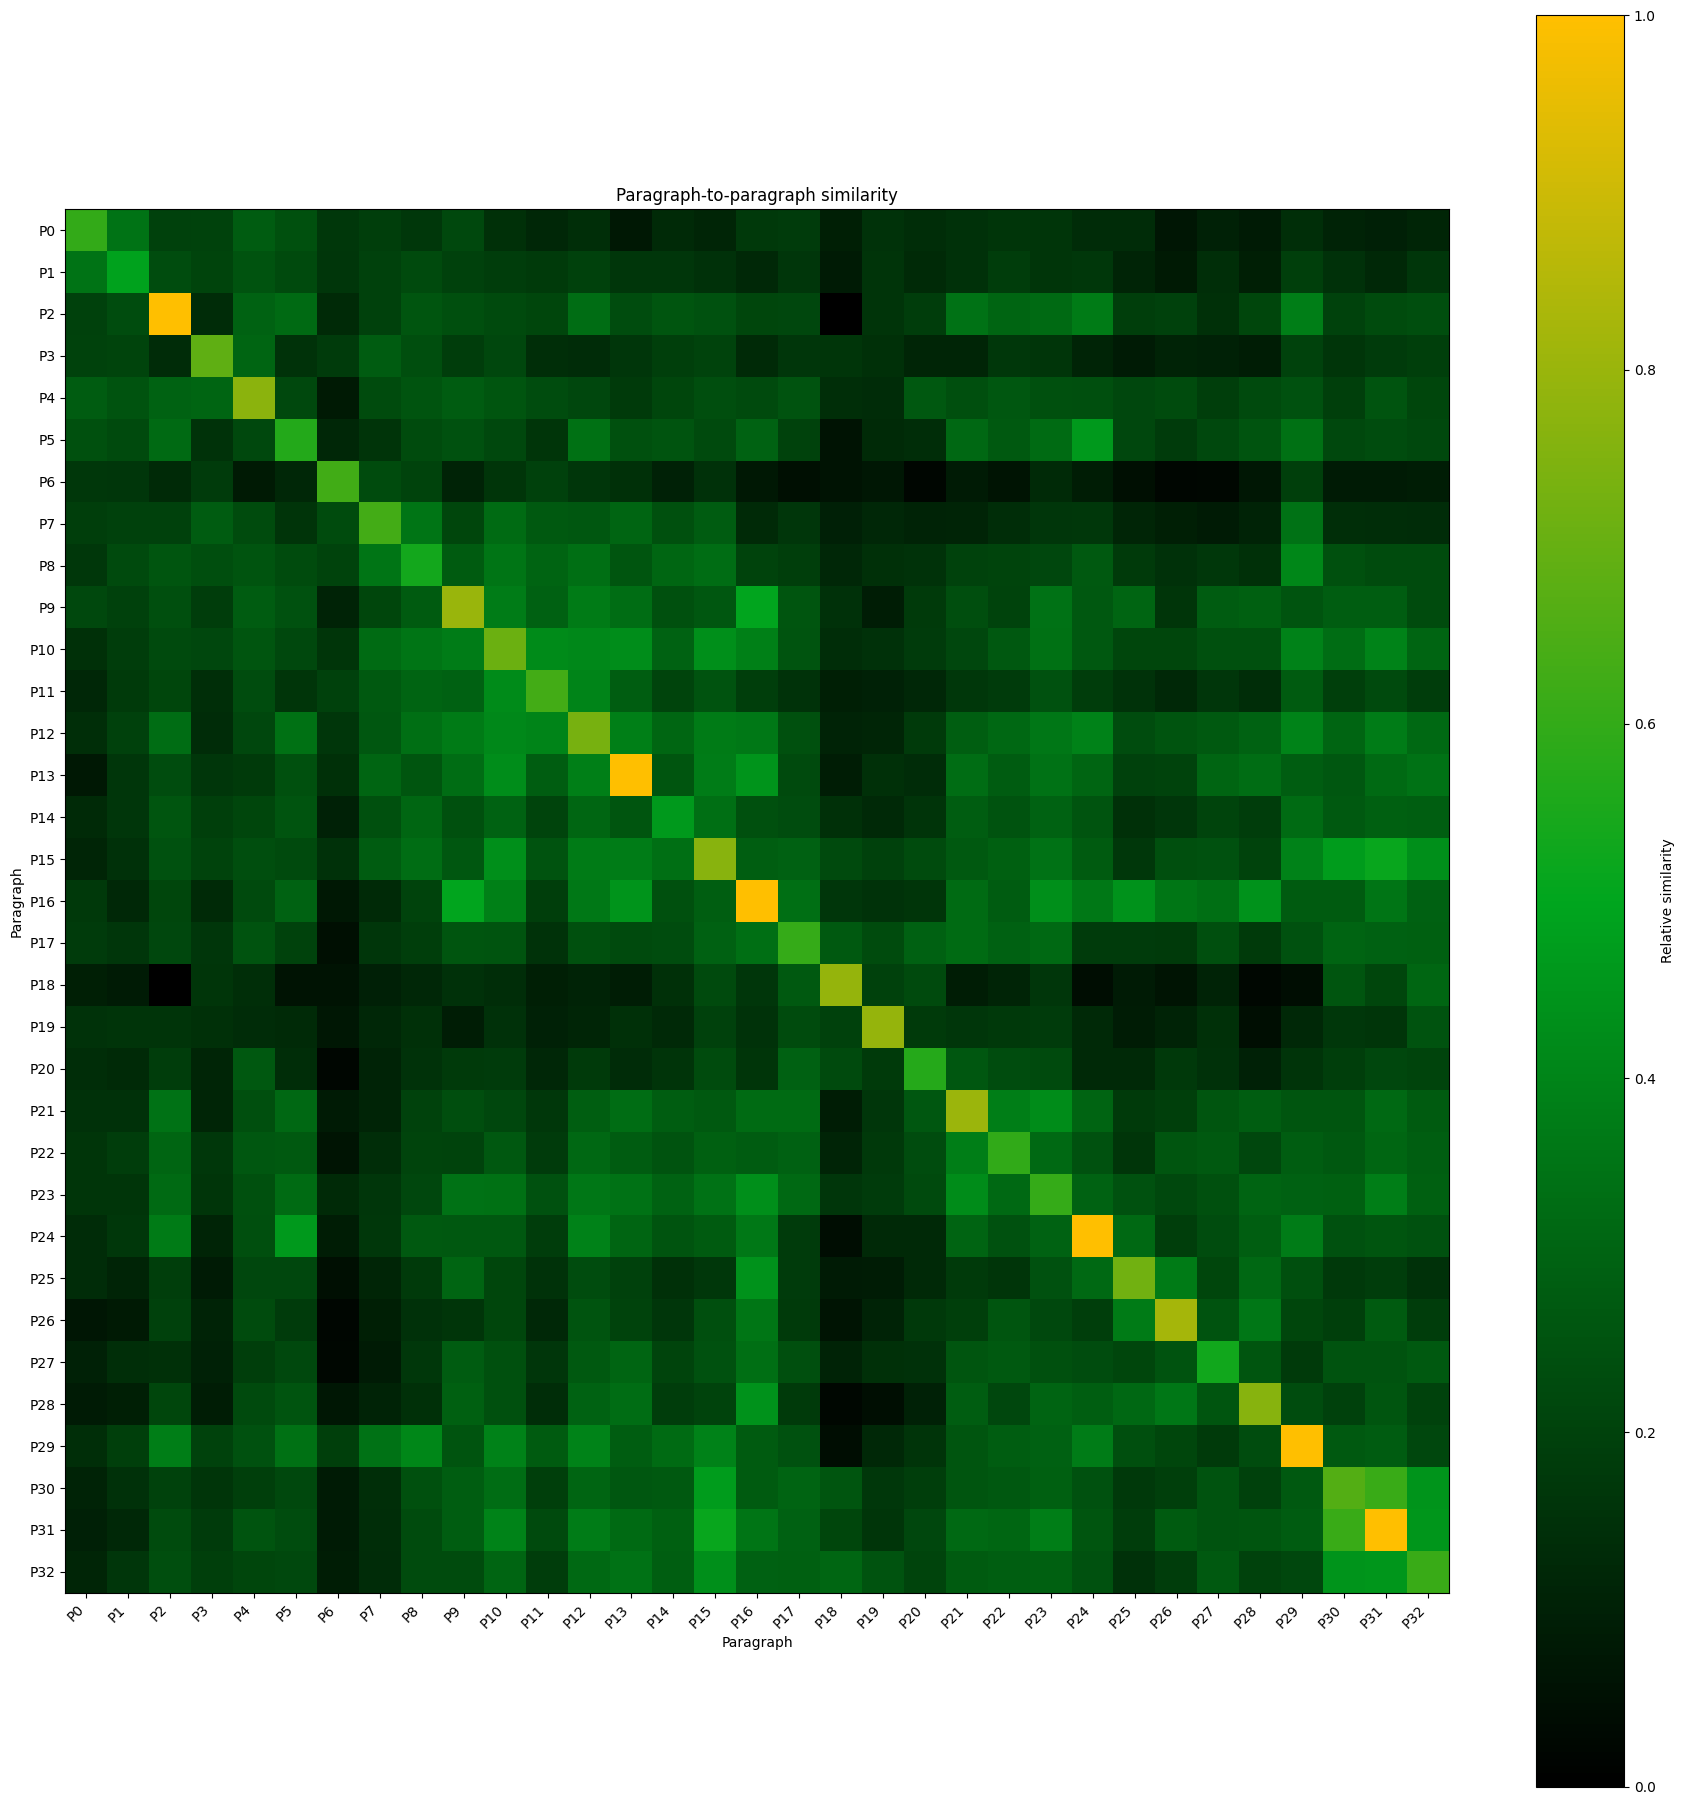

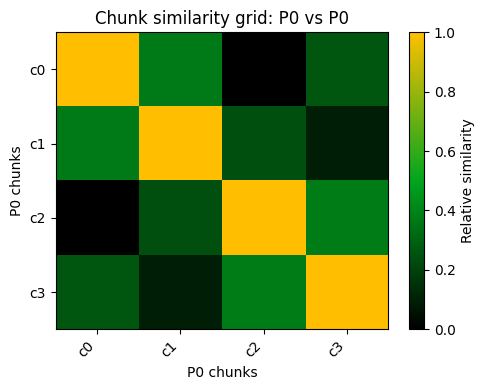


=== P0 vs P0 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
Most similar chunks (score=1.0003): P0 c1 <-> P0 c1
P0 c1: manage an e-commerce platform. After huddling around a whiteboard for a few hours to ponder the problem, we might settle on the broad strokes of a working solution, for example: (i) users interact with the application...
P0 c1: manage an e-commerce platform. After huddling around a whiteboard for a few hours to ponder the problem, we might settle on the broad strokes of a working solution, for example: (i) users interact with the application...


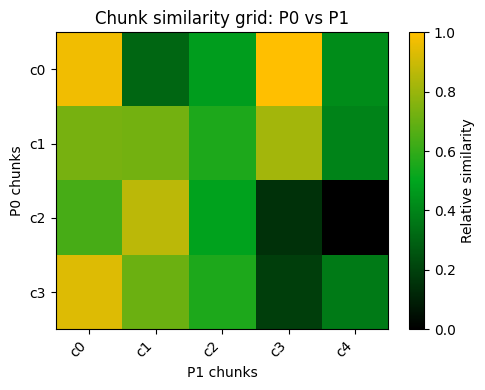


=== P0 vs P1 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P1 text: To build the brains of our application, we might enumerate all the common events that our program should handle. For example, whenever a our program should handle. For example, whenever a customer clicks to add an ite...
Most similar chunks (score=0.4922): P0 c0 <-> P1 c3
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P1 c3: with an empty cart? While few developers ever get it completely right the first time (it might take some test runs to work out the kinks), for the most part we can write such programs and confidently launch them befor...


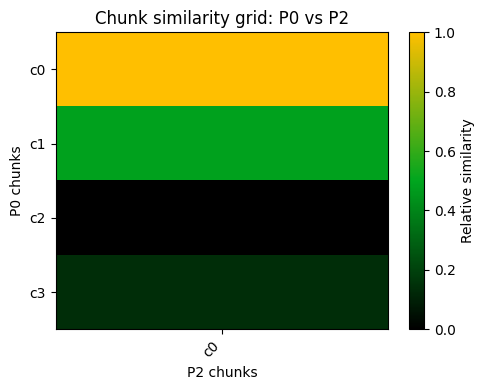


=== P0 vs P2 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P2 text: Fortunately for the growing community of machine learning scientists, many tasks that we would like to automate do not bend so easily to human ingenuity. Imagine huddling around the
Most similar chunks (score=0.4198): P0 c0 <-> P2 c0
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P2 c0: Fortunately for the growing community of machine learning scientists, many tasks that we would like to automate do not bend so easily to human ingenuity. Imagine huddling around the


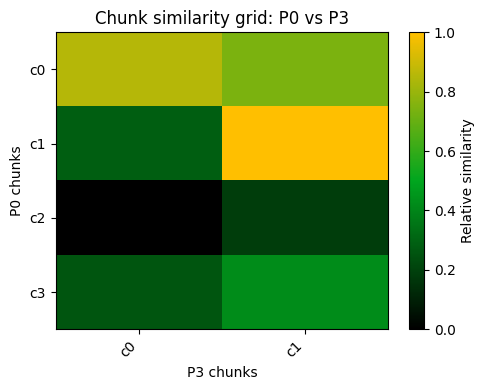


=== P0 vs P3 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P3 text: Write a program that predicts tomorrow's weather given geographic information, satellite images, and a trailing window of past weather. Write a program that takes in a factoid question, expressed in free-form text, an...
Most similar chunks (score=0.3884): P0 c1 <-> P3 c1
P0 c1: manage an e-commerce platform. After huddling around a whiteboard for a few hours to ponder the problem, we might settle on the broad strokes of a working solution, for example: (i) users interact with the application...
P3 c1: and answers it correctly. Write a program that, given an image, identifies every person depicted in it and draws outlines around each. Write a program that presents users with products that they are likely to enjoy bu...


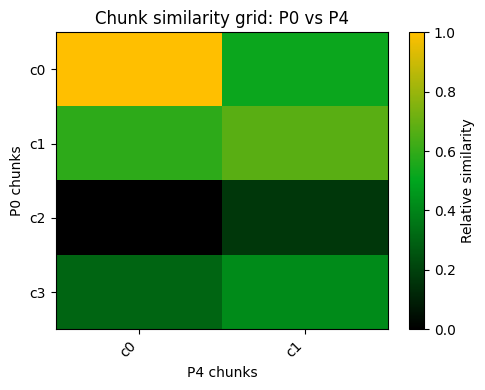


=== P0 vs P4 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P4 text: For these problems, even elite programmers would struggle to code up solutions from scratch. The reasons can vary. Sometimes the program that we are looking for follows a pattern that changes over time, so there is no...
Most similar chunks (score=0.5239): P0 c0 <-> P4 c0
P0 c0: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P4 c0: For these problems, even elite programmers would struggle to code up solutions from scratch. The reasons can vary. Sometimes the program that we are looking for follows a pattern that changes over time, so there is no...


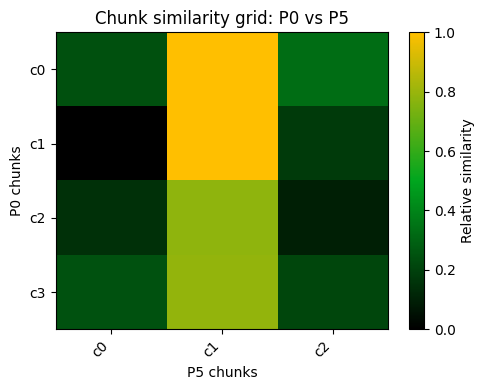


=== P0 vs P5 ===
P0 text: Until recently, nearly every computer program that you might have interacted with during an ordinary day was coded up as a rigid set of rules specifying precisely how it should behave. Say that we wanted to write an a...
P5 text: Machine learning is the study of algorithms that can learn from experience. As a machine learning algorithm accumulates more experience, typically in the form of observational data or interactions with an environment,...
Most similar chunks (score=0.5140): P0 c1 <-> P5 c1
P0 c1: manage an e-commerce platform. After huddling around a whiteboard for a few hours to ponder the problem, we might settle on the broad strokes of a working solution, for example: (i) users interact with the application...
P5 c1: environment, its performance improves. Contrast this with our deterministic e-commerce platform, which follows the same business logic, no matter how much experience accrues, until the developers themselves learn and ...


In [ ]:
class cosine_similarity(SimilarityFormula):
    def compute_similarity(self, embedding1, embedding2):
        denom = np.linalg.norm(embedding1) * np.linalg.norm(embedding2)
        if denom == 0:
            return 0.0
        return np.dot(embedding1, embedding2) / denom
    
class euclidean_similarity(SimilarityFormula):
    def compute_similarity(self, embedding1, embedding2): # type: ignore
        return 1 / (1 + np.linalg.norm(embedding1 - embedding2))
    
class dot_similarity(SimilarityFormula):
    def compute_similarity(self, embedding1, embedding2):
        return np.dot(embedding1, embedding2)

class manhattan_similarity(SimilarityFormula):
    def compute_similarity(self, embedding1, embedding2):
        return 1 / (1 + np.sum(np.abs(embedding1 - embedding2)))

similarity_analyzer = SimilarityAnalyzer()
results1 = similarity_analyzer.compare(manager.data_frame, manager.paragraphs[-3], euclidean_similarity())

similarity_displayer = SimilarityDisplayer()
similarity_displayer.show_paragraph_grid(results1, manager.paragraphs)
similarity_displayer.show_chunk_grids_by_paragraph_pair(results1, manager.paragraphs, max_pairs=6)

results2 = similarity_analyzer.compare(manager.data_frame, manager.paragraphs[-2], cosine_similarity())
similarity_displayer.show_paragraph_grid(results2, manager.paragraphs)
similarity_displayer.show_chunk_grids_by_paragraph_pair(results2, manager.paragraphs, max_pairs=6)

results3 = similarity_analyzer.compare(manager.data_frame, manager.paragraphs[-1], dot_similarity())
similarity_displayer.show_paragraph_grid(results3, manager.paragraphs)
similarity_displayer.show_chunk_grids_by_paragraph_pair(results3, manager.paragraphs, max_pairs=6)
